# Weather Prediction Using Markov Chain

## 1 Introduction

Since powerful computers became available, scientists have used numerical models to better understand how the weather works.

One method used for weather prediction is the analog method. This method looks at past weather patterns that are similar to the current weather, and predicts the future based on what happened before. Markov Chain is a great tool for this because it assumes that tomorrow's weather depends only on today's weather — not what happened in the past.

In this project, we study the weather in Seoul, the capital of South Korea, using weather data from 2022 to 2024.

The weather dataset used in this project was obtained from Kaggle, specifically from the dataset titled *Seoul Historical Weather Data (2024)*.

This dataset contains detailed historical weather information for Seoul, including variables such as temperature, humidity, wind speed, and weather conditions (e.g., clear-day, rain, snow) from January 1, 2022 to January 1, 2024. It serves as the foundation for building and analyzing a Markov chain model of daily weather transitions.

## 2 Dataset Overview

### 2.1 Importing Libraries

In this section, we import the essential Python libraries required for data analysis, visualization, and graph-based operations:

- **pandas** and **numpy**: For handling and processing structured data efficiently.
- **matplotlib.pyplot**: For creating static and statistical visualizations.
- **networkx**: For creating and analyzing complex networks and graph structures.
- **collections.defaultdict** and **functools.reduce**: For simplifying dictionary operations with default values.
- **math**: For performing mathematical operations.

These libraries provide the core functionality needed throughout the project for data manipulation, plotting, and algorithmic logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import networkx as nx
from collections import defaultdict, Counter
from functools import reduce
from math import gcd

### 2.2 Loading the Dataset

We load the dataset containing Seoul-related data from January 1, 2022 to January 1, 2024 using the pandas library. The CSV file is read into a DataFrame, which is a two-dimensional labeled data structure.

After loading, we use the `head()` method to preview the first five rows of the dataset. This helps verify that the file was loaded correctly and provides a quick overview of the structure and content of the data, including column names, data types, and sample values.

In [3]:
# Load CSV file into a DataFrame
df = pd.read_csv("seoul 2022-01-01 to 2024-01-01.csv")

# Show first 5 rows of the DataFrame
df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,seoul,2022-01-01,2.0,-10.2,-4.7,0.3,-15.0,-6.6,-15.2,44.3,...,9.9,5,NaN,2022-01-01T07:46:54,2022-01-01T17:24:04,0.94,Clear,Clear conditions throughout the day.,clear-day,"47098099999,47112099999,47119099999,4712209999..."
1,seoul,2022-01-02,2.6,-4.4,-1.1,-0.5,-8.6,-4.0,-8.4,58.9,...,10.1,5,NaN,2022-01-02T07:47:03,2022-01-02T17:24:52,0.98,"Snow, Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"47111099999,47098099999,47112099999,4711909999..."
2,seoul,2022-01-03,2.2,-7.7,-2.4,0.6,-11.5,-4.7,-10.1,56.4,...,9.8,5,NaN,2022-01-03T07:47:10,2022-01-03T17:25:41,0.00,"Snow, Rain, Partially cloudy",Becoming cloudy in the afternoon with late aft...,rain,"47111099999,47098099999,47112099999,4711909999..."
3,seoul,2022-01-04,1.0,-5.0,-1.9,0.6,-9.1,-4.7,-10.6,54.8,...,10.9,5,NaN,2022-01-04T07:47:15,2022-01-04T17:26:32,0.04,Snow,Clear conditions throughout the day with late ...,rain,"47111099999,47098099999,47112099999,4711909999..."
4,seoul,2022-01-05,1.7,-7.7,-3.1,1.7,-12.0,-4.9,-13.0,46.7,...,6.1,3,NaN,2022-01-05T07:47:18,2022-01-05T17:27:23,0.08,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"47111099999,47098099999,47112099999,4711909999..."


### 2.3 Getting Information About the Dataset

In this section, we use the `info()` method to display a concise summary of the DataFrame. This includes:

- Column names
- Data types of each column (e.g., int, float, object)
- Non-null counts to identify missing data
- Memory usage of the DataFrame

This overview is essential for understanding the dataset's structure and for planning data cleaning and preprocessing steps.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              731 non-null    object 
 1   datetime          731 non-null    object 
 2   tempmax           731 non-null    float64
 3   tempmin           731 non-null    float64
 4   temp              731 non-null    float64
 5   feelslikemax      731 non-null    float64
 6   feelslikemin      731 non-null    float64
 7   feelslike         731 non-null    float64
 8   dew               731 non-null    float64
 9   humidity          731 non-null    float64
 10  precip            731 non-null    float64
 11  precipprob        731 non-null    int64  
 12  precipcover       731 non-null    float64
 13  preciptype        345 non-null    object 
 14  snow              731 non-null    float64
 15  snowdepth         731 non-null    float64
 16  windgust          731 non-null    float64
 1

### 2.4 Checking for Missing Values

In this study, we focus our analysis on two key variables: the `icon` column, which represents the weather condition category (e.g., clear-day, rain, snow), and the `datetime` column, which provides the corresponding timestamps for each observation.

To ensure data quality, we use `df.isnull().sum()` to check for missing values in all columns. The result shows that there are no missing values in the columns we will be working with, confirming that the dataset is clean and ready for analysis.

In [5]:
df.isnull().sum()

name                  0
datetime              0
tempmax               0
tempmin               0
temp                  0
feelslikemax          0
feelslikemin          0
feelslike             0
dew                   0
humidity              0
precip                0
precipprob            0
precipcover           0
preciptype          386
snow                  0
snowdepth             0
windgust              0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility            0
solarradiation        0
solarenergy           0
uvindex               0
severerisk            9
sunrise               0
sunset                0
moonphase             0
conditions            0
description           0
icon                  0
stations              0
dtype: int64

## 3 Defining the Markov Chain Framework

Weather transitions over time in the analog method can be modeled using a Markov process: the probability of transitioning to the next state depends solely on the current state, and not on the sequence of states that preceded it. So let $X_t$ represent the weather state at time $t$. Based on this property, the process $\{X_t : t \in T\}$ is a Markov process.

In our project, the weather is observed once per day. This means that the time set $T$ can be written as:

$$T = \{t_0, t_1, \dots, t_n\} \text{ where } t_0 = \text{2022-01-01},\ t_1 = \text{2022-01-02}, \dots, t_n = \text{2024-01-01}.$$

Because the values in $T$ are countable, we consider $T$ to be a discrete time set. As a result, the Markov process $\{X_t : t \in T\}$ is a discrete-time process.

To define the state space of this Markov process, we examine the unique values in the `icon` column, which represent distinct weather condition categories. Using `df.icon.value_counts()`, we enumerate the frequency of each weather condition, which forms the discrete state space of the model.

In [6]:
df.icon.value_counts()

icon
partly-cloudy-day    312
rain                 253
clear-day            118
snow                  40
cloudy                 8
Name: count, dtype: int64

In this context, 5 observed states are used:

$$S = \{\text{clear-day},\ \text{partly-cloudy-day},\ \text{rain},\ \text{snow},\ \text{cloudy}\}$$

Because the values in $S$ are countable, we consider $S$ to be a discrete space set. As a result, the Markov process $\{X_t : t \in T\}$ is a discrete-state process.

Given that both the time set $T$ and the state space $S$ are discrete, the Markov process $\{X_t : t \in T\}$ qualifies as a Markov chain.

### 3.1 Preprocessing and State Encoding

Before building and analyzing the Markov chain model, we need to clean the dataset and prepare the state space. This preprocessing step ensures the dataset is structured properly for Markov modeling and visual analysis of weather transitions.

In [7]:
# Get a sorted list of all unique weather conditions from the 'icon' column
states = sorted(df['icon'].unique())

# Create a dictionary that maps each weather condition to a unique integer index
state_map = {state: i for i, state in enumerate(states)}

# Count the total number of unique weather states
n_states = len(states)
state_map

{'clear-day': 0, 'cloudy': 1, 'partly-cloudy-day': 2, 'rain': 3, 'snow': 4}

In [8]:
# Convert the 'datetime' column to proper datetime format for time-based operations
df['datetime'] = pd.to_datetime(df['datetime'])

# Keep only the 'datetime' and 'icon' columns for analysis
df = df[["datetime", "icon"]]

# Sort the DataFrame by date and reset the index
df = df.sort_values('datetime').reset_index(drop=True)

### 3.2 Visualizing the Markov Chain

To better understand how the weather evolves day-by-day in our Markov chain framework, we visualize the sequence of weather states over the first 100 days and last 100 days in the dataset.

In the plot:
- Each point on the line represents the weather condition for one day, mapped numerically based on the state space from the `icon` column.
- The x-axis shows the date, while the y-axis displays the corresponding weather state (e.g., clear-day, rain, snow).
- A line connects the daily states to reveal transitions and patterns over time.

#### 3.2.1 First 100 Days

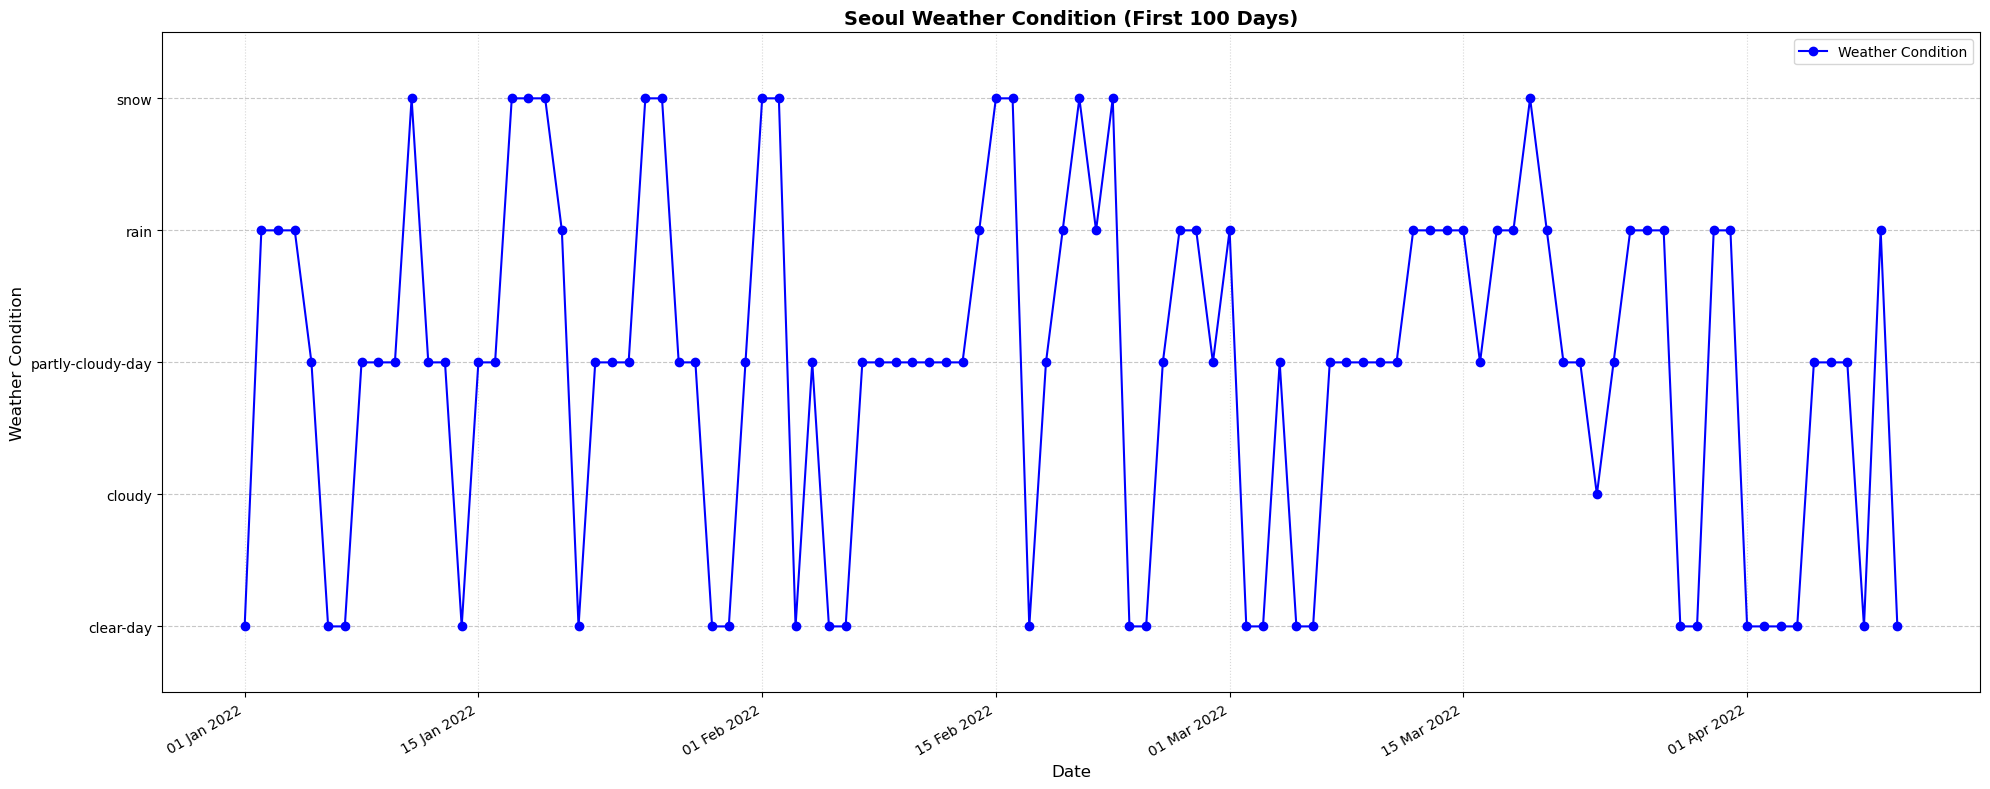

In [9]:
# Prepare data: get first 100 weather states and their corresponding dates
icons = df['icon'].tolist()
dates = df['datetime'].tolist()[:100]
y_values = [state_map[icon] for icon in icons[:100] if icon in state_map]

# Plot settings
plt.figure(figsize=(20, 8))  # Create a wide figure
if y_values:
    # Plot the weather condition over time
    plt.plot(dates[:len(y_values)], y_values, marker='o', linestyle='-', color='blue',
             markersize=6, linewidth=1.5, label='Weather Condition')

    # Set y-axis to display state names
    plt.yticks(ticks=range(n_states), labels=states, fontsize=10)
    plt.ylim(-0.5, n_states - 0.5)

    # Format x-axis to show readable dates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gcf().autofmt_xdate()

    # Add labels, title, and grids
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Weather Condition", fontsize=12)
    plt.title("Seoul Weather Condition (First 100 Days)", fontsize=14, fontweight='bold')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.grid(True, axis='x', linestyle=':', alpha=0.5)

    # Add legend and display plot
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

#### 3.2.2 Last 100 Days

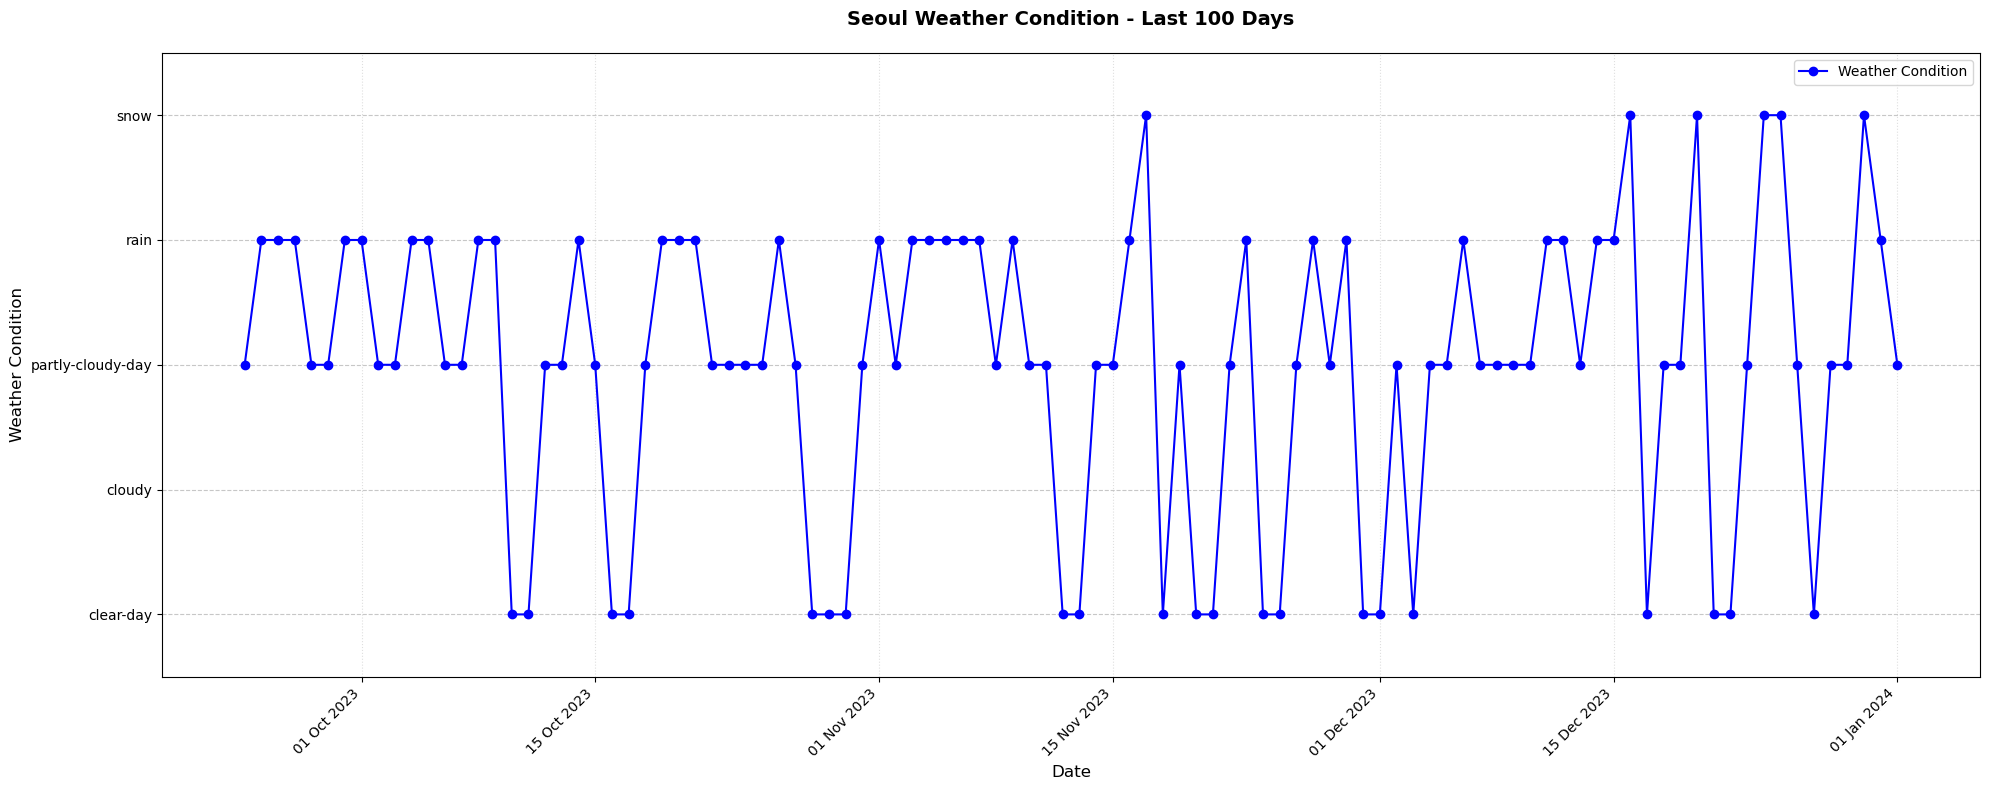

In [10]:
# Get the last 100 rows of the DataFrame
df_last100 = df.tail(100)

# Extract icons and dates
icons = df_last100['icon'].tolist()
dates = df_last100['datetime'].tolist()

# Map weather conditions to numeric values
y_values = [state_map[icon] for icon in icons if icon in state_map]

# Set up the figure
plt.figure(figsize=(20, 8))  # Wide plot for better date spacing
if y_values:
    # Plot the weather condition trend
    plt.plot(dates, y_values, marker='o', linestyle='-', color='blue',
             markersize=6, linewidth=1.5, label='Weather Condition')

    # Set y-axis to display weather state names
    plt.yticks(ticks=range(n_states), labels=states, fontsize=10)
    plt.ylim(-0.5, n_states - 0.5)

    # Format x-axis to show readable dates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gcf().autofmt_xdate(rotation=45, ha='right')  # Rotate date labels
    plt.subplots_adjust(bottom=0.2)  # Space for rotated labels

    # Add grid lines
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.grid(True, axis='x', linestyle=':', alpha=0.4)

    # Add axis labels
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Weather Condition", fontsize=12)

    # Add a title
    plt.title("Seoul Weather Condition - Last 100 Days", fontsize=14, fontweight='bold', pad=20)

    # Show legend and adjust layout
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()

    # Show the plot
    plt.show()

### 3.3 Defining One-Step Transition Probability Matrix

A Markov process is said to be **time-homogeneous** (or **stationary**) if its transition probabilities do not change over time. In other words, the probability of transitioning from one state to another depends only on the current state — not on the specific time at which the transition occurs.

In our project, these probabilities are assumed to be fixed over time. That is, the likelihood of transitioning from, say, clear-day to rain, is treated as the same on any day, regardless of whether it occurs in January 2022 or October 2023.

We know that the probability of transitioning from state $i$ to state $j$ in one step is given by:

$$P(X_{t+1} = j \mid X_t = i)$$

However, based on the earlier description, we assume that the transition probabilities do not depend on time. So we can simplify the notation by writing the transition probabilities as $p_{ij}$ instead of $p_{ij}^{t \to t+1}$.

The transition matrix $P$ defines the probabilities of moving from one state to another. Thus, the matrix $P$ is written as:

$$P = (p_{ij}) \text{ for } i, j \in S$$

These probabilities must reflect the real behavior of the system being modeled — in this case, daily weather patterns.

To estimate these probabilities accurately, we rely on empirical data — the actual observed transitions between weather states in the dataset.

The matrix $P$ is estimated directly from the frequency of observed transitions in the data. This ensures the model is based on real-world behavior rather than assumptions:

$$p_{ij} = \frac{\text{Number of times weather transitioned from state } i \text{ to state } j}{\text{Total number of times the system was in state } i}$$

In [11]:
# Initialize dictionaries to count transitions
transition_counts = defaultdict(lambda: defaultdict(int))  # Nested count dictionary
state_totals = defaultdict(int)  # Total transitions from each state

# Convert the weather column to a list for easy iteration
icons = df['icon'].tolist()

# Count transitions from each state to the next
for i in range(len(icons) - 1):
    from_state = icons[i]
    to_state = icons[i + 1]
    if from_state in state_map and to_state in state_map:
        transition_counts[from_state][to_state] += 1
        state_totals[from_state] += 1

# Initialize the transition matrix (P) with zeros
P = np.zeros((n_states, n_states))

# Fill the matrix with transition probabilities
for i, from_state in enumerate(states):
    total_from = state_totals[from_state]
    if total_from > 0:
        for j, to_state in enumerate(states):
            count = transition_counts[from_state][to_state]
            P[i, j] = count / total_from  # Probability = count / total transitions from state

# Convert matrix P to a labeled DataFrame for easier viewing
P_df = pd.DataFrame(P, index=states, columns=states)

# Display the transition probability matrix
print("One-Step Transition Probability Matrix (P):\n")
print(P_df.round(3))  # Round to 3 decimals for readability

One-Step Transition Probability Matrix (P):

                   clear-day  cloudy  partly-cloudy-day   rain   snow
clear-day              0.373   0.000              0.525  0.085  0.017
cloudy                 0.000   0.125              0.500  0.375  0.000
partly-cloudy-day      0.148   0.023              0.495  0.289  0.045
rain                   0.071   0.000              0.320  0.573  0.036
snow                   0.225   0.000              0.275  0.125  0.375


A matrix $A = (a_{ij})$ is a **stochastic matrix** (also called a random matrix), if the following two conditions are satisfied:

1. **Non-Negative Probabilities:**

$$0 \le a_{ij} \le 1 \text{ for all } i, j$$

2. **Row Sum Equals One:**

$$\sum_{j=1}^{n} a_{ij} = 1 \text{ for all } i$$

It's clear that the transition matrix $P$ must be a stochastic matrix. We can check these conditions for our matrix:

In [12]:
# Condition 1: Check if all entries in the transition matrix are between 0 and 1
valid_entries = np.all((P >= 0) & (P <= 1))

# Condition 2: Calculate the sum of each row in the transition matrix
row_sums = P.sum(axis=1)

# Check if each row sum is approximately equal to 1 (with a small tolerance for floating-point errors)
row_sum_check = np.allclose(row_sums, 1.0, atol=1e-6)

# Verify both conditions and print whether P is a valid stochastic matrix
if valid_entries and row_sum_check:
    print("\nThe transition matrix P is a valid stochastic matrix.")
else:
    print("\nThe transition matrix P is NOT a valid stochastic matrix.")


The transition matrix P is a valid stochastic matrix.


### 3.4 Visualizing One-Step Transition Probability Matrix

To gain a clearer understanding of how weather states transition from one to another, we visualize the transition matrix $P$ as a heatmap.

This heatmap provides a visual summary of the one-step transition probabilities between different weather states. Each cell in the matrix represents the probability of transitioning from a source state (row) to a target state (column). Higher probabilities are shown with darker shades of blue.

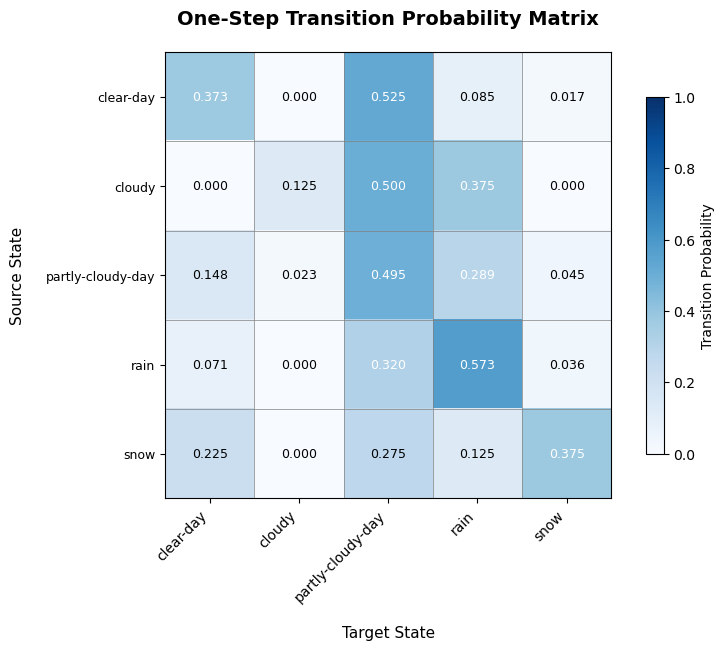

In [13]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(9, 7))  # Set figure size

# Display the matrix P as a heatmap
cax = ax.imshow(P, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)

# Add a color bar to indicate the probability scale
fig.colorbar(cax, label='Transition Probability', shrink=0.8)

# Set tick positions and labels for x and y axes
ax.set_xticks(np.arange(n_states))
ax.set_yticks(np.arange(n_states))
ax.set_xticklabels(states, rotation=45, ha='right', fontsize=10)  # X labels rotated for readability
ax.set_yticklabels(states, fontsize=9)

# Label axes
ax.set_xlabel("Target State", fontsize=11, labelpad=15)
ax.set_ylabel("Source State", fontsize=11, labelpad=15)

# Ensure ticks are at the bottom of the heatmap
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()

# Annotate each cell with the transition probability (rounded to 3 decimal places)
threshold = P.max() / 2  # For choosing text color
for i in range(n_states):
    for j in range(n_states):
        prob = P[i, j]
        text_color = "white" if prob > threshold else "black"
        ax.text(j, i, f"{prob:.3f}", ha='center', va='center',
                color=text_color, fontsize=9,
                bbox=dict(facecolor='none', edgecolor='none', alpha=0.3))  # Optional: light background

# Add minor ticks for better grid placement
ax.set_xticks(np.arange(n_states) - 0.5, minor=True)
ax.set_yticks(np.arange(n_states) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", size=0)

# Add title
plt.title('One-Step Transition Probability Matrix', pad=20, fontsize=14, fontweight='bold')

# Adjust layout
plt.tight_layout(pad=2.5)

# Display the plot
plt.show()

Any Markov chain can be described by a directed graph called the transition graph of the Markov chain, where the nodes/vertices represent the states of the chain and the transition probabilities between pairs of states are marked next to the arcs/edges.

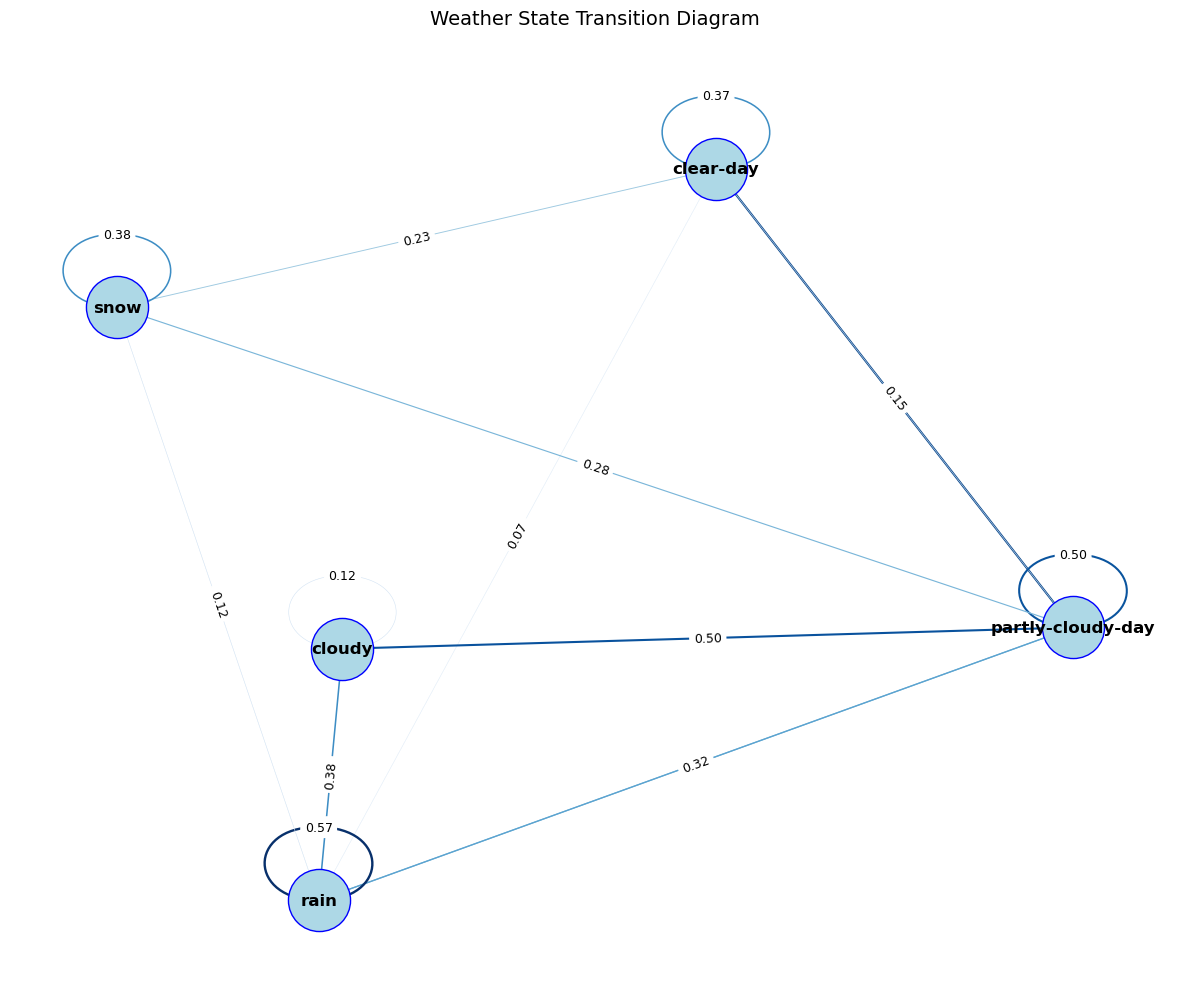

In [14]:
# Create a directed graph to represent state transitions
G = nx.DiGraph()

# Add edges to the graph for transitions with probability > 1%
for i in range(n_states):
    for j in range(n_states):
        if P[i, j] > 0.01:
            G.add_edge(states[i], states[j], weight=P[i, j], label=f"{P[i, j]:.2f}")

# Set up the figure for plotting
plt.figure(figsize=(12, 10))

# Generate positions for nodes using a force-directed layout (reproducible with seed)
pos = nx.spring_layout(G, seed=42)

# Define edge thickness and color based on transition probabilities
edge_widths = [3 * G[u][v]['weight'] for u, v in G.edges()]
edge_colors = [G[u][v]['weight'] for u, v in G.edges()]

# Draw the nodes with color and edge styling
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='blue')

# Draw the directed edges with color intensity and arrow style based on weight
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors,
                        edge_cmap=plt.cm.Blues, arrowstyle='->', arrowsize=20)

# Add labels to the nodes
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Create a dictionary of edge labels and draw them on the graph
edge_labels = {(u, v): G[u][v]['label'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

# Add a title to the plot
plt.title("Weather State Transition Diagram", fontsize=14, pad=20)

# Hide axis for cleaner visual
plt.axis('off')

# Adjust layout for better spacing
plt.tight_layout()

# Show the final graph
plt.show()

### 3.5 Visualizing Multi-Step Transition Probability Matrix

In a Markov process, the transition matrix $P$ represents the probabilities of moving from one state to another in a single step. However, we are often interested in understanding the system's behavior over multiple time steps.

To achieve this, we compute powers of the transition matrix:

- $P^2$: Two-step transition probabilities
- $P^{10}$: Ten-step transition probabilities
- $P^{100}$: One-Hundred-step transition probabilities

These matrices are computed using `np.linalg.matrix_power()`, which efficiently raises the matrix $P$ to the desired power.

In [15]:
P2 = np.linalg.matrix_power(P, 2)     # Compute the 2-step transition probability matrix (P squared)
P10 = np.linalg.matrix_power(P, 10)   # Compute the 10-step transition probability matrix (P to the power of 10)
P100 = np.linalg.matrix_power(P, 100) # Compute the 100-step transition probability matrix (long-run behavior)

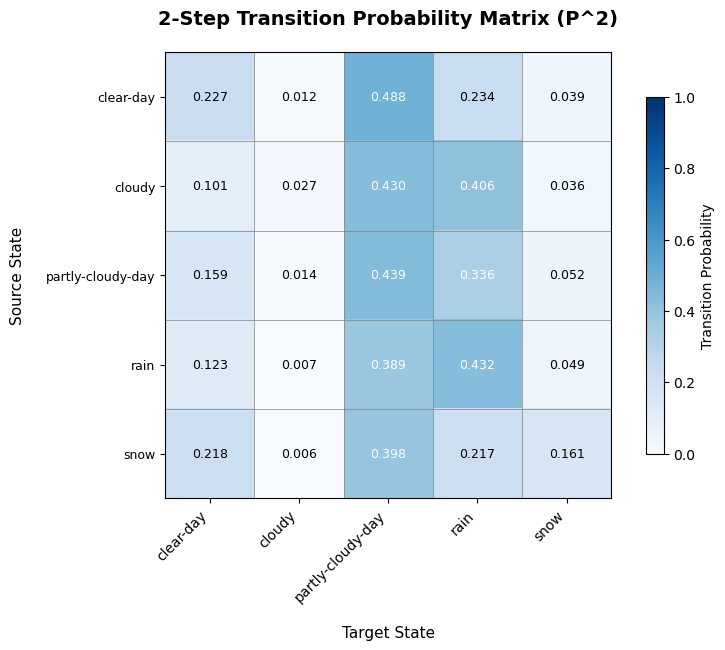

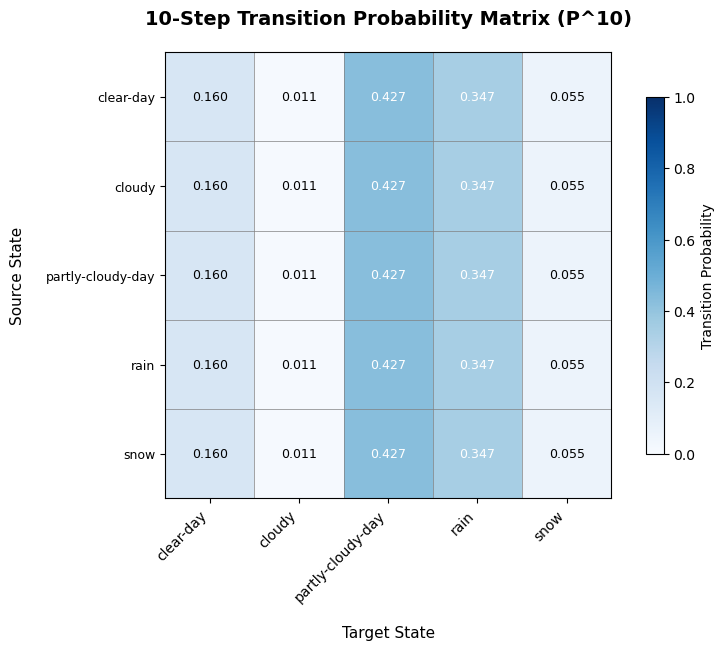

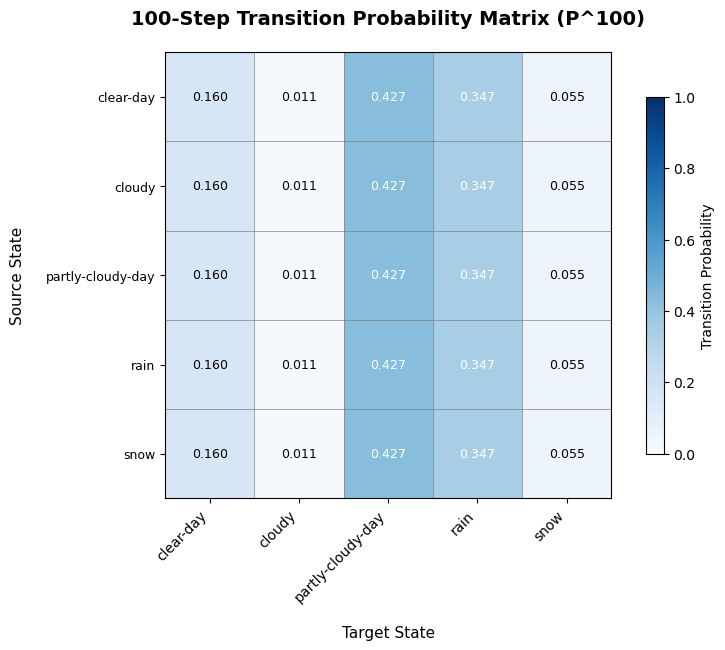

In [16]:
# Create a dictionary that maps step counts to their corresponding transition matrices
matrices_to_plot = {
    2: P2,     # 2-step transition matrix
    10: P10,   # 10-step transition matrix
    100: P100  # 100-step transition matrix
}

# Loop through each matrix and its corresponding step count
for n, Pn in matrices_to_plot.items():
    # Create a new figure and axis for each plot with a defined size
    fig, ax = plt.subplots(figsize=(9, 7))

    # Display the transition matrix Pn as a heatmap
    cax = ax.imshow(Pn, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)

    # Add a color bar to show the range and scale of probabilities
    fig.colorbar(cax, label='Transition Probability', shrink=0.8)

    # Set tick positions and labels for x and y axes based on state indices
    ax.set_xticks(np.arange(n_states))
    ax.set_yticks(np.arange(n_states))
    ax.set_xticklabels(states, rotation=45, ha='right', fontsize=10)  # Rotate X labels for readability
    ax.set_yticklabels(states, fontsize=9)

    # Add axis labels for context
    ax.set_xlabel("Target State", fontsize=11, labelpad=15)
    ax.set_ylabel("Source State", fontsize=11, labelpad=15)

    # Ensure x-axis labels appear at the bottom
    ax.xaxis.set_label_position('bottom')
    ax.xaxis.tick_bottom()

    # Annotate each cell with its transition probability (rounded to 3 decimals)
    threshold = Pn.max() / 2  # Determine text color threshold based on matrix max value
    for i in range(n_states):
        for j in range(n_states):
            prob = Pn[i, j]
            text_color = "white" if prob > threshold else "black"  # Improve readability based on contrast
            ax.text(j, i, f"{prob:.3f}", ha='center', va='center',
                    color=text_color, fontsize=9,
                    bbox=dict(facecolor='none', edgecolor='none', alpha=0.3))  # Optional subtle background

    # Add minor ticks between main cells for grid visibility
    ax.set_xticks(np.arange(n_states) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_states) - 0.5, minor=True)

    # Add a light grid using the minor ticks
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)

    # Set the title for the plot with the current step count
    plt.title(f'{n}-Step Transition Probability Matrix (P^{n})', pad=20, fontsize=14, fontweight='bold')

    # Adjust layout for clean spacing
    plt.tight_layout(pad=2.5)

    # Show the final heatmap
    plt.show()

## 4 Analyzing the Weather Prediction Model

### 4.1 Checking Existence of Absorbing State

In a Markov chain, a state $i$ ($i \in S$) is **absorbing** if $p_{ii} = 1$. It means that once the system enters state $i$, it stays there forever and cannot transition to any other state.

In [17]:
# Initialize an empty list to store absorbing states (if any)
absorbing_states = []

# Loop through the diagonal of the transition matrix P
for i in range(len(P)):
    if P[i, i] == 1:
        # If the probability of staying in the same state is 1, it's an absorbing state
        absorbing_states.append(states[i])

# Print the result based on whether absorbing states were found
if absorbing_states:
    print("The weather prediction model has absorbing state(s):")
    print("Absorbing states:", absorbing_states)
else:
    print("The weather prediction model has no absorbing states.")

The weather prediction model has no absorbing states.


In our weather prediction model, there are no absorbing states, meaning the weather can always change from one condition to another. The system never gets stuck in a single state forever, which makes sense because real weather is always changing over time (e.g., even if it rains for several days, it will eventually stop).

### 4.2 Finding Equivalence Classes and Checking Irreducibility

Two states $i$ and $j$ belong to the same equivalence class if:

- $i 	o j$: state $j$ is reachable from state $i$, and
- $j 	o i$: state $i$ is reachable from state $j$

Such states are said to *communicate* with each other, and the set of all states that mutually communicate forms an equivalence (communication) class.

In [18]:
# Number of states
n = P.shape[0]

# Create a directed graph from the transition matrix
G = nx.DiGraph()
for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G.add_edge(i, j)

# Find strongly connected components (equivalence classes)
components = list(nx.strongly_connected_components(G))

# Map indices back to state names if available
equiv_classes = [
    [states[i] for i in sorted(comp)]
    for comp in components
]

# Display the equivalence (communication) classes
print("Equivalence (communication) classes:")
for i, cls in enumerate(equiv_classes, 1):
    print(f"Class {i}: {cls}")

Equivalence (communication) classes:
Class 1: ['clear-day', 'cloudy', 'partly-cloudy-day', 'rain', 'snow']


A Markov chain is **irreducible** if it is possible to reach every other state from any given state. It means that there is only one non-empty equivalence class that includes all states. Since all weather states are part of a single equivalence class, our weather prediction model is irreducible.

Irreducibility implies that the weather model can transition from any weather condition to any other, given enough time. For example, it may go from rain to clear-day, or from snow to cloudy, possibly through intermediate states.

This aligns well with real-world weather behavior, where conditions naturally evolve and no weather type is permanently isolated.

### 4.3 Computing State Periods and Checking Aperiodicity

For a Markov chain, the period of state $i \in S$, denoted as $d(i)$, is the greatest common divisor (GCD) of all numbers that represent the possible number of steps to return to state $i$:

$$d(i) = \gcd\left\{ n \ge 1 : p_{ii}^{(n)} > 0 \right\}$$

States within an equivalence (communication) class all have the same period.

In [19]:
# Set maximum number of steps to search for return paths
max_power = 100
n = P.shape[0]
periods = [0] * n  # To store the period of each state

# Loop through each state
for i in range(n):
    return_steps = []  # Time steps at which state i returns to itself

    # Start with identity matrix as P^0
    P_power = np.eye(n)

    # Multiply P up to max_power times
    for k in range(1, max_power + 1):
        P_power = P_power @ P  # Compute P^k
        if P_power[i, i] > 1e-6:  # If there's non-zero probability of returning to state i
            return_steps.append(k)

    # Compute GCD of all return steps
    if return_steps:
        periods[i] = reduce(gcd, return_steps)
    else:
        periods[i] = None  # No return within max_power steps

# Display the period of each state
print("Period of each state:\n")
for i, p in enumerate(periods):
    print(f"State '{states[i]}' => Period = {p}")

Period of each state:

State 'clear-day' => Period = 1
State 'cloudy' => Period = 1
State 'partly-cloudy-day' => Period = 1
State 'rain' => Period = 1
State 'snow' => Period = 1


A Markov chain is **aperiodic** if every state in the chain has period 1.

Since the period of every state in our weather prediction is 1, the Markov chain is aperiodic. This implies that the system can return to each state at irregular times, and the chain does not follow fixed periodic cycles.

### 4.4 Long-Term Weather Analysis

#### 4.4.1 Stationary Distribution

A **stationary distribution** in a Markov chain is a probability distribution $\pi = [\pi_1, \pi_2, \pi_3, \dots]$ (i.e. $\sum_{i \in S} \pi_i = 1$, $\pi_i \ge 0$) that satisfies the equation:

$$\pi = \pi P$$

It can also be written using its component-wise form as:

$$\pi_i = \sum_{j \in S} \pi_j p_{ji} \quad i, j \in S$$

If a Markov chain starts with its stationary distribution, then at every time step, the distribution over the states remains the same as the initial distribution. In other words, the chain preserves its probabilistic structure over time.

#### 4.4.2 Limiting Distribution

The vector $\pi = [\pi_1, \pi_2, \pi_3, \dots]$ is called the **limiting distribution** of a Markov chain $X_t$ if:

$$\pi_j = \lim_{n \to \infty} p_{ij}^{n} \text{ for all } i, j \in S$$

This means that, as the number of steps $n$ becomes very large, the probability of being in state $j$ converges to a fixed value $\pi_j$, regardless of the starting state $i$.

The limiting distribution is a probability distribution, so it must satisfy:

$$\sum_{j \in S} \pi_j = 1$$

**Interpretation:**

- The limiting distribution describes the long-run behavior of the Markov chain.
- It tells us the proportion of time the system spends in each state as $n \to \infty$.

**Theorem:** Consider a finite Markov chain (Markov chain with a finite number of states) $\{X_t, t = 0, 1, 2, \dots\}$ where $X_t \in S = \{0, 1, 2, \dots, r\}$.

Assume that the chain is irreducible and aperiodic. Then,

- The set of equations $\pi = \pi P$, $\sum_{j \in S} \pi_j = 1$ has a unique solution.
- The unique solution to the above equations is the limiting distribution of the Markov chain, i.e., $\pi_j = \lim_{n \to \infty} p_{ij}^{n}$, for all $i, j \in S$.
- We have $r_j = \frac{1}{\pi_j}$, for all $j \in S$ where $r_j$ is the mean return time to state $j$.

It means that aperiodicity, together with irreducibility, ensures that the chain can converge to a unique stationary (limiting) distribution.

Since these conditions hold for our model, the stationary distribution can therefore be computed:

In [20]:
P_T = P.T  # Transpose to find left eigenvectors

# Get eigenvalues and right eigenvectors of P^T
eigenvalues, eigenvectors = np.linalg.eig(P_T)

# Find the index of eigenvalue 1 (or very close to 1 numerically)
index = np.argmin(np.abs(eigenvalues - 1))
stationary = np.real(eigenvectors[:, index])  # Get corresponding eigenvector

# Normalize to make it a probability distribution
pi = stationary / np.sum(stationary)

# Print result
print("Stationary distribution:\n")
for state, prob in zip(states, pi):
    print(f"{state}: {prob:.4f}")

Stationary distribution:

clear-day: 0.1598
cloudy: 0.0110
partly-cloudy-day: 0.4272
rain: 0.3471
snow: 0.0549


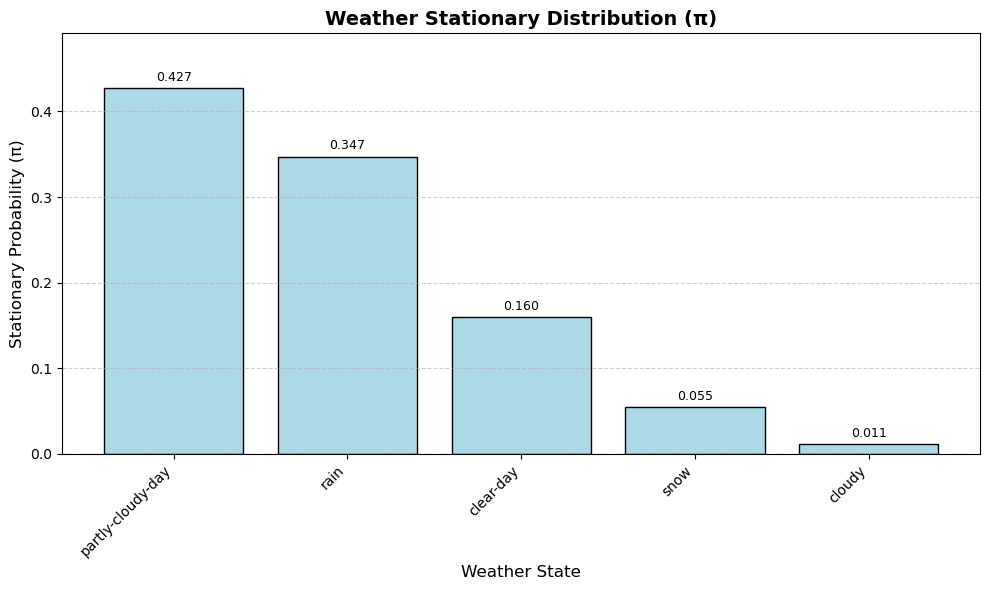

In [21]:
# Create a dictionary mapping each weather state to its stationary probability
stationary_dist_dict = {state: prob for state, prob in zip(states, pi)}

# Create a figure for the bar plot
plt.figure(figsize=(10, 6))

# Sort states by their stationary probabilities in descending order
sorted_states = sorted(stationary_dist_dict, key=stationary_dist_dict.get, reverse=True)
sorted_probs = [stationary_dist_dict[state] for state in sorted_states]

# Create a bar plot of the stationary distribution
bars = plt.bar(sorted_states, sorted_probs, color='lightblue', edgecolor='black')

# Annotate each bar with the corresponding probability value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005,
              f"{yval:.3f}", ha='center', va='bottom', fontsize=9)

# Set axis labels and plot title
plt.xlabel("Weather State", fontsize=12)
plt.ylabel("Stationary Probability (π)", fontsize=12)
plt.title("Weather Stationary Distribution (π)", fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Set y-axis limit slightly above max value for spacing
plt.ylim(0, max(pi) * 1.15 if max(pi) > 0 else 0.1)

# Add horizontal grid lines to y-axis
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

Based on the computed stationary distribution, the long-term probabilities of weather states — regardless of the initial condition — are:

- Clear Day: 0.1598 → 15.98%
- Cloudy: 0.0110 → 1.10%
- Partly Cloudy Day: 0.4272 → 42.72%
- Rain: 0.3471 → 34.71%
- Snow: 0.0549 → 5.49%

These values indicate the steady-state likelihood of each weather condition occurring in the long run.

#### 4.4.3 Limiting Matrix

The limiting matrix represents the long-term behavior of an ergodic (irreducible and aperiodic) Markov chain. As the number of steps $n$ becomes very large, the $n$-step transition matrix $P^n$ converges to a matrix where each row is equal to the stationary distribution vector $\pi$.

This matrix is computed by repeating the stationary distribution across all rows:

- Each row in the limiting matrix shows the long-run probabilities of being in each state, regardless of the initial state.
- Mathematically: $\lim_{n \to \infty} P^n = \pi$

In this code:

- `np.tile(pi, (n_states, 1))` replicates the stationary distribution vector $\pi$ across all rows.
- The resulting matrix is converted to a DataFrame for easier viewing, with state names as both row and column labels.

This limiting matrix confirms that, in the long run, the system forgets its initial state and stabilizes to a predictable distribution of outcomes.

In [26]:
# Create the limiting matrix: each row is the stationary distribution
limiting_matrix = np.tile(pi, (n_states, 1))  # Repeat pi as rows

# Convert to DataFrame for nicer display
limiting_df = pd.DataFrame(limiting_matrix, index=states, columns=states)

# Print or display the limiting matrix
print("\nLimiting Matrix:\n")
print(limiting_df.round(4))


Limiting Matrix:

                   clear-day  cloudy  partly-cloudy-day    rain    snow
clear-day             0.1598   0.011             0.4272  0.3471  0.0549
cloudy                0.1598   0.011             0.4272  0.3471  0.0549
partly-cloudy-day     0.1598   0.011             0.4272  0.3471  0.0549
rain                  0.1598   0.011             0.4272  0.3471  0.0549
snow                  0.1598   0.011             0.4272  0.3471  0.0549


#### 4.4.4 Trajectory Simulation

To better understand the behavior of the Markov chain in practice, we simulate a trajectory of 100 steps starting from a uniform initial distribution:

$$\pi_0 = \left\{ \frac{1}{5}, \frac{1}{5}, \frac{1}{5}, \frac{1}{5}, \frac{1}{5} \right\}$$

After generating the trajectory, we calculate both the absolute and relative frequencies of visits to each state. The absolute frequency counts how many times each state was visited, while the relative frequency shows the proportion of time spent in each state. These empirical results give insight into the behavior of the system over time and can be compared with the stationary distribution to assess convergence to long-run equilibrium behavior.

In [22]:
# Uniform initial distribution
pi_0 = np.full(n_states, 1 / n_states)  # Uniform distribution over all states

# Simulate 100-step trajectory
np.random.seed(42)  # For reproducibility
trajectory = []
current_state = np.random.choice(n_states, p=pi_0)  # Initial state
trajectory.append(current_state)

for _ in range(99):  # Total 100 steps
    next_state = np.random.choice(n_states, p=P[current_state])
    trajectory.append(next_state)
    current_state = next_state

# Convert trajectory indices to state labels
trajectory_states = [states[i] for i in trajectory]

# Compute absolute and relative frequency
abs_freq = Counter(trajectory_states)
rel_freq = {state: count / len(trajectory_states) for state, count in abs_freq.items()}

# Display trajectory as a table
trajectory_df = pd.DataFrame({
    'Step': list(range(1, len(trajectory_states) + 1)),
    'Weather State': trajectory_states
})
print("\nTrajectory Table (First 20 Steps):")
display(trajectory_df.head(20))

# Display frequency as a table
frequency_df = pd.DataFrame({
    'Weather State': states,
    'Absolute Frequency': [abs_freq.get(state, 0) for state in states],
    'Relative Frequency': [rel_freq.get(state, 0) for state in states]
})
print("\nFrequency Table:")
display(frequency_df)


Trajectory Table (First 20 Steps):


,Step,Weather State
0,1,cloudy
1,2,rain
2,3,rain
3,4,rain
4,5,partly-cloudy-day
5,6,cloudy
6,7,cloudy
7,8,rain
8,9,rain
9,10,rain



Frequency Table:


,Weather State,Absolute Frequency,Relative Frequency
0,clear-day,21,0.21
1,cloudy,3,0.03
2,partly-cloudy-day,42,0.42
3,rain,26,0.26
4,snow,8,0.08


We observe that the relative frequencies differ greatly from the result of the stationary distribution. Therefore, we can increase the number of replications to observe that, with a very large number of them, the distribution of relative frequencies tends towards the stationary distribution.

In [23]:
# Uniform initial distribution
pi_0 = np.full(n_states, 1 / n_states)  # Uniform distribution over all states

# Simulate 10^5-step trajectory
np.random.seed(42)  # For reproducibility
trajectory = []
current_state = np.random.choice(n_states, p=pi_0)  # Initial state
trajectory.append(current_state)

for _ in range(99999):  # Total 10^5 steps
    next_state = np.random.choice(n_states, p=P[current_state])
    trajectory.append(next_state)
    current_state = next_state

# Convert trajectory indices to state labels
trajectory_states = [states[i] for i in trajectory]

# Compute absolute and relative frequency
abs_freq = Counter(trajectory_states)
rel_freq = {state: count / len(trajectory_states) for state, count in abs_freq.items()}

# Display trajectory as a table
trajectory_df = pd.DataFrame({
    'Step': list(range(1, len(trajectory_states) + 1)),
    'Weather State': trajectory_states
})
print("\nTrajectory Table (First 20 Steps):")
display(trajectory_df.head(20))

# Display frequency as a table
frequency_df = pd.DataFrame({
    'Weather State': states,
    'Absolute Frequency': [abs_freq.get(state, 0) for state in states],
    'Relative Frequency': [rel_freq.get(state, 0) for state in states]
})
print("\nFrequency Table:")
display(frequency_df)


Trajectory Table (First 20 Steps):


,Step,Weather State
0,1,cloudy
1,2,rain
2,3,rain
3,4,rain
4,5,partly-cloudy-day
5,6,cloudy
6,7,cloudy
7,8,rain
8,9,rain
9,10,rain



Frequency Table:


,Weather State,Absolute Frequency,Relative Frequency
0,clear-day,15940,0.15940
1,cloudy,1149,0.01149
2,partly-cloudy-day,42783,0.42783
3,rain,34813,0.34813
4,snow,5315,0.05315


We note that the results are very similar, and of course, with an even greater number of steps, they will tend to be perfectly equal.

In [24]:
# Create the comparison table: Relative Frequency vs Stationary Distribution
comparison_df = pd.DataFrame({
    'Weather State': states,
    'Relative Frequency': [rel_freq.get(state, 0) for state in states],
    'Stationary Distribution': [pi[i] for i in range(n_states)]
})

# Set 'Weather State' as the index for cleaner display
comparison_df.set_index('Weather State', inplace=True)

# Display table
display(comparison_df)

,Relative Frequency,Stationary Distribution
Weather State,,
clear-day,0.15940,0.159827
cloudy,0.01149,0.010990
partly-cloudy-day,0.42783,0.427239
rain,0.34813,0.347083
snow,0.05315,0.054861


#### 4.4.5 Average Turnaround Time

For our irreducible Markov chain, we will calculate the average return time to the state from which it started, which is the average number of transitions or steps in which the chain revisits a certain state.

For these calculations, use the formula:

$$r_j = \frac{1}{\pi_j}, \text{ for all } j \in S$$

where $r_j$ is the mean return time to state $j$ and $\pi$ is the unique stationary distribution.

In [25]:
# Calculate mean return times using the stationary distribution
mean_return_times = [1 / prob if prob > 0 else float('inf') for prob in pi]

# Format return times with "days"
mean_return_times_formatted = [f"{rt:.2f} days" for rt in mean_return_times]

# Create a DataFrame
return_time_df = pd.DataFrame({
    'Weather State': states,
    'Stationary Probability (π)': pi,
    'Mean Return Time (r = 1/π)': mean_return_times_formatted
})

# Set index for cleaner formatting
return_time_df.set_index('Weather State', inplace=True)

# Display table
display(return_time_df)

,Stationary Probability (π),Mean Return Time (r = 1/π)
Weather State,,
clear-day,0.159827,6.26 days
cloudy,0.010990,90.99 days
partly-cloudy-day,0.427239,2.34 days
rain,0.347083,2.88 days
snow,0.054861,18.23 days
